# Imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
from pathlib import Path

from PIL import Image

from torchvision.transforms import v2 as T
import torchvision.transforms.functional as F

from typing import List, Union

import torch #PyTorch

from tqdm.notebook import tqdm

import cv2 #OpenCV

# Setup

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Config
# Path to dataset (Each group member may need to modify this)
DATASET_RAW_FILEPATH_IN_DRIVE = "/content/drive/MyDrive/COMP-SCI 5530 - Principles of Data Science/Project/data_clean/data_clean_v3.zip"

In [4]:
# Copy data clean zip from Google Drive
!cp "{DATASET_RAW_FILEPATH_IN_DRIVE}" "/content/data_raw.zip"

In [5]:
# Unzip data raw zip
!unzip "/content/data_raw.zip"

Streaming output truncated to the last 5000 lines.
  inflating: data_clean/Train/Fake/fake_51216.jpg_0  
  inflating: data_clean/Train/Fake/fake_20451.jpg_0  
  inflating: data_clean/Train/Fake/fake_23564.jpg_0  
  inflating: data_clean/Train/Fake/fake_52180.jpg_0  
  inflating: data_clean/Train/Fake/fake_14623.jpg_1  
  inflating: data_clean/Train/Fake/fake_6036.jpg_0  
  inflating: data_clean/Train/Fake/fake_30158.jpg_0  
  inflating: data_clean/Train/Fake/fake_29598.jpg_0  
  inflating: data_clean/Train/Fake/fake_15116.jpg_0  
  inflating: data_clean/Train/Fake/fake_46947.jpg_0  
  inflating: data_clean/Train/Fake/fake_34492.jpg_0  
  inflating: data_clean/Train/Fake/fake_2002.jpg_0  
  inflating: data_clean/Train/Fake/fake_10953.jpg_0  
  inflating: data_clean/Train/Fake/fake_10916.jpg_0  
  inflating: data_clean/Train/Fake/fake_16158.jpg_1  
  inflating: data_clean/Train/Fake/fake_32262.jpg_1  
  inflating: data_clean/Train/Fake/fake_59548.jpg_0  
  inflating: data_clean/Train/Fak

In [6]:
# Print GPU info
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: False
GPU: None


In [7]:
# Attempt to run on GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on:", device)

Running on: cpu


# Testing

In [8]:
class ResizeAndPad:
    def __init__(self, target_size, fill=0):
        self.target_h, self.target_w = target_size
        self.fill = fill

    def __call__(self, img):
        w, h = img.size  # PIL: (width, height)

        if w > self.target_w:
          img.thumbnail((self.target_w, h))
          w, h = img.size  # PIL: (width, height)
        if h > self.target_h:
          img.thumbnail((w, self.target_h))
          w, h = img.size  # PIL: (width, height)

        pad_h = max(self.target_h - h, 0)
        pad_w = max(self.target_w - w, 0)

        # Split padding evenly (center the image)
        padding = (
            pad_w // 2,                    # left
            pad_h // 2,                    # top
            pad_w - pad_w // 2,            # right
            pad_h - pad_h // 2             # bottom
        )

        return F.pad(img, padding, fill=self.fill)

In [15]:
img_size = 150

# Base transforms for val, test, and inference
base_transforms = T.Compose([
  ResizeAndPad((img_size, img_size)),

  T.ToImage(),
  T.ToDtype(torch.float32, scale=True),
])

(90, 124)
torch.Size([3, 150, 150])


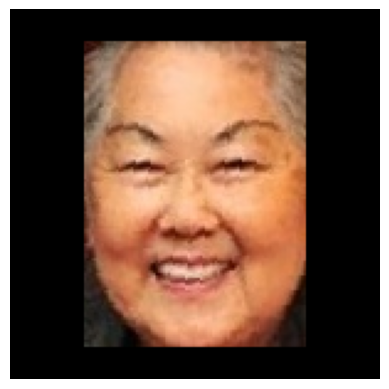

In [16]:
# 1. Prepare image (Ensure it starts as PIL for your transforms)
img_path = "/content/data_clean/Train/Real/real_13223.jpg_0"
img_pil = Image.open(img_path).convert("RGB")
print(img_pil.size)
# 2. Apply your Compose
img_out = base_transforms(img_pil)
print(img_out.size())
# 3. Show in Colab
# Since your error proved it's a (3, 200, 200) Tensor:
plt.imshow(img_out[[2, 1, 0], :, :].permute(1, 2, 0))
plt.axis('off')
plt.show()
